
<h1><center><font color=skyblue>
    <br> Text-to-Image Generation in Game Design
    </font></center></h1>


## Deep Learning - Final Project
*   Lujain Ahmad - 202201738
*   Habiba Khalil - 202200720
*   Farida Mohammed - 202202579
*   Youssef Abohendia - 202202699


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torch.cuda import amp
import torchvision.utils as vutils
import torch.nn.functional as F
import torch.optim as optim
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler
from torchvision.utils import make_grid
import clip
import numpy as np
from google.colab import drive


device = 'cuda' if torch.cuda.is_available() else 'cpu'
IMAGE_SIZE = 64
LATENT_DIM = 100
BATCH_SIZE = 64

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp "/content/drive/MyDrive/archive.zip" .
!unzip -q archive.zip -d midjourney_subset
!ls midjourney_subset

replace midjourney_subset/images/0000ab68-73e1-4163-ab3d-2cbc8378e1b9__crop1.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
images	prompts.csv


In [ ]:
csv_path = "/content/midjourney_subset/prompts.csv"
df = pd.read_csv(csv_path)

In [ ]:
image_dir = "/content/midjourney_subset/images"
df['image_path'] = df['img_name'].apply(lambda x: os.path.join(image_dir, x) if pd.notnull(x) else None)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, _ = clip.load("ViT-B/32", device=device)

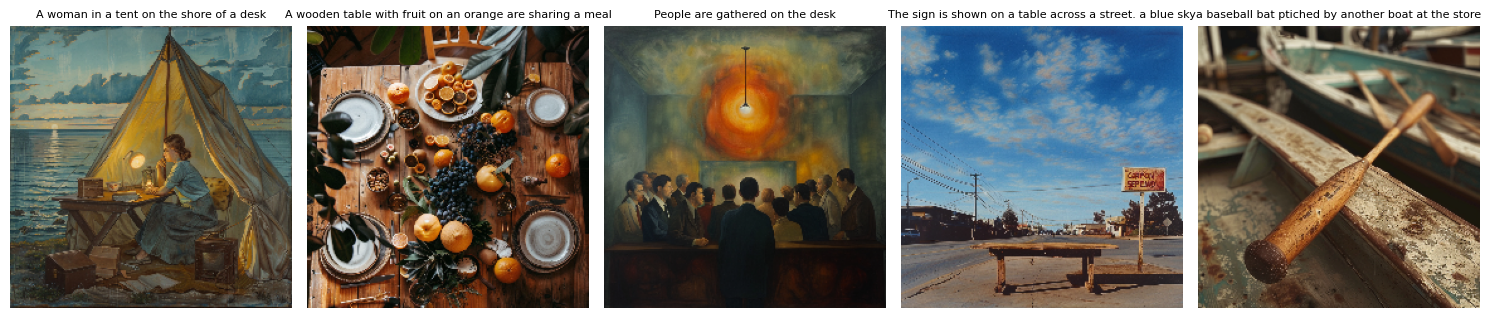

In [ ]:
num_images = 5
image_dir = "/content/midjourney_subset/images"

df_clean = df.dropna(subset=['img_name']).reset_index(drop=True)
sample_df = df_clean.sample(num_images, random_state=42)

fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img_path = os.path.join(image_dir, row['img_name'])
    try:
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(row['prompt'], fontsize=8, wrap=True)
        ax.axis('off')
    except Exception as e:
        print(f"❌ Could not open {img_path}: {e}")
        ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df_clean = df[
    df['img_name'].apply(
        lambda x: os.path.isfile(os.path.join(image_dir, x)) if isinstance(x, str) else False
    )
].reset_index(drop=True)

print(f"Cleaned dataset size: {len(df_clean)}")

Cleaned dataset size: 127967


In [ ]:
# Function to encode prompts
def encode_prompts(prompts, batch_size=64):
    all_embeddings = []
    num_batches = (len(prompts) + batch_size - 1) // batch_size
    for i in range(num_batches):
        batch = prompts[i*batch_size:(i+1)*batch_size]
        tokens = clip.tokenize(batch).to(device)
        with torch.no_grad(), torch.amp.autocast(device_type=device):
            embeds = clip_model.encode_text(tokens)
            embeds /= embeds.norm(dim=-1, keepdim=True)
        all_embeddings.append(embeds.cpu())
    return torch.cat(all_embeddings)

# === Step 4: Generate prompt embeddings for cleaned dataframe ===
prompts = df_clean['prompt'].astype(str).tolist()
prompt_embeddings = encode_prompts(prompts)

In [ ]:
transform_size = 64
transform = transforms.Compose([
    transforms.Resize((transform_size, transform_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

In [ ]:
class LazyImageDataset(Dataset):
    def __init__(self, df, image_dir, prompt_embeddings, transform):
        self.df = df
        self.image_dir = image_dir
        self.prompt_embeddings = prompt_embeddings
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = str(self.df.iloc[idx]['img_name'])
        img_path = os.path.join(self.image_dir, img_name)
        try:
            image = Image.open(img_path).convert("RGB")
            image = self.transform(image)
            prompt_embed = self.prompt_embeddings[idx]
        except Exception as e:
            print(f"Warning: Could not load image {img_name} at index {idx}: {e}")
            image = torch.zeros(3, transform_size, transform_size)
            prompt_embed = torch.zeros_like(self.prompt_embeddings[0])
        return image, prompt_embed

dataset = LazyImageDataset(df_clean, image_dir, prompt_embeddings, transform)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

In [ ]:
# --- Models ---

LATENT_DIM = 100

class ConditionalGenerator(nn.Module):
    def __init__(self, embed_dim, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc = nn.Linear(latent_dim + embed_dim, 128 * 8 * 8)
        self.main = nn.Sequential(
            nn.BatchNorm1d(128 * 8 * 8),
            nn.ReLU(True),
            nn.Unflatten(1, (128, 8, 8)),
            nn.ConvTranspose2d(128, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z, prompt_embed):
        x = torch.cat((z, prompt_embed), dim=1)
        x = self.fc(x)
        return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 1),
        )

    def forward(self, x):
        return self.main(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = ConditionalGenerator(embed_dim=prompt_embeddings.shape[1]).to(device)
D = Discriminator().to(device)

In [ ]:
criterion = nn.BCEWithLogitsLoss()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [ ]:
scaler_G = amp.GradScaler()
scaler_D = amp.GradScaler()

<ipython-input-57-8d398ed6f616>:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G = amp.GradScaler()
<ipython-input-57-8d398ed6f616>:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_D = amp.GradScaler()


# Training

In [ ]:
from torch.cuda import amp

EPOCHS = 100
LATENT_DIM = 100

for epoch in range(1, EPOCHS + 1):
    total_acc = 0
    total_batches = 0
    loop = tqdm(loader, desc=f"Epoch {epoch}")

    for real_imgs, prompt_embeds in loop:
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        prompt_embeds = prompt_embeds.to(device).float()

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)
        z = torch.randn(batch_size, LATENT_DIM, device=device)

        # Train Discriminator
        with amp.autocast():
            fake_imgs = G(z, prompt_embeds)
            real_out = D(real_imgs)
            fake_out = D(fake_imgs.detach())

            real_loss = criterion(real_out, real_labels)
            fake_loss = criterion(fake_out, fake_labels)
            d_loss = (real_loss + fake_loss) / 2

        opt_D.zero_grad()
        scaler_D.scale(d_loss).backward()
        scaler_D.step(opt_D)
        scaler_D.update()

        # Train Generator
        with amp.autocast():
            fake_imgs = G(z, prompt_embeds)
            g_loss = criterion(D(fake_imgs), real_labels)

        opt_G.zero_grad()
        scaler_G.scale(g_loss).backward()
        scaler_G.step(opt_G)
        scaler_G.update()

        # Accuracy calculation
        with torch.no_grad():
            real_probs = torch.sigmoid(real_out)
            fake_probs = torch.sigmoid(fake_out)

            real_preds = real_probs >= 0.5
            fake_preds = fake_probs < 0.5
            correct = (real_preds.sum() + fake_preds.sum()).item()
            accuracy = correct / (2 * batch_size)

        total_acc += accuracy
        total_batches += 1
        loop.set_postfix({'D Loss': d_loss.item(), 'G Loss': g_loss.item(), 'D Acc': accuracy})

    avg_acc = total_acc / total_batches
    print(f"Epoch {epoch} | Avg D Acc: {avg_acc:.4f}")

Epoch 1:   0%|          | 0/3999 [00:00<?, ?it/s]<ipython-input-58-c95eed63c754>:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
<ipython-input-58-c95eed63c754>:36: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
Epoch 1: 100%|██████████| 3999/3999 [02:46<00:00, 24.00it/s, D Loss=0.191, G Loss=3.15, D Acc=0.984]


Epoch 1 | Avg D Acc: 0.9221


Epoch 2: 100%|██████████| 3999/3999 [02:46<00:00, 24.07it/s, D Loss=0.0717, G Loss=4.26, D Acc=1]


Epoch 2 | Avg D Acc: 0.9403


Epoch 3: 100%|██████████| 3999/3999 [02:45<00:00, 24.16it/s, D Loss=0.296, G Loss=0.966, D Acc=0.823]


...

Epoch 98 | Avg D Acc: 0.9907


Epoch 99: 100%|██████████| 3999/3999 [02:46<00:00, 24.00it/s, D Loss=0.0217, G Loss=5.81, D Acc=1]


Epoch 99 | Avg D Acc: 0.9896


Epoch 100: 100%|██████████| 3999/3999 [02:46<00:00, 24.08it/s, D Loss=0.00758, G Loss=5.29, D Acc=1]

Epoch 100 | Avg D Acc: 0.9899


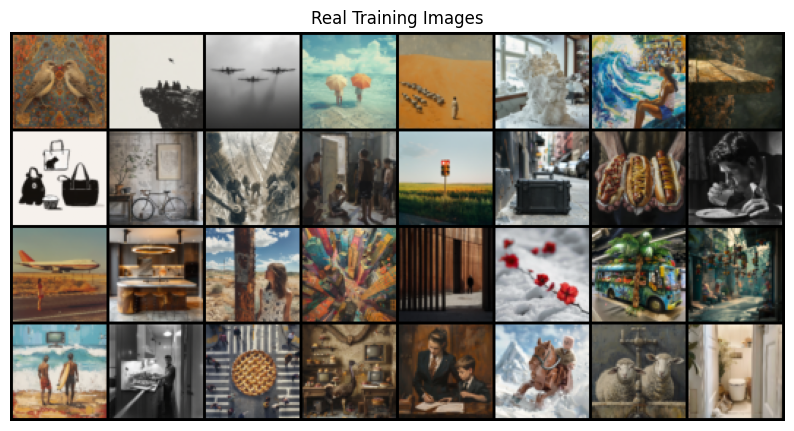

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Get one batch from your dataloader
real_images_batch, _ = next(iter(loader))  # if your dataset returns (image, embedding)

# If images are normalized with mean=0.5 and std=0.5, denormalize:
def denormalize(tensor):
    mean = 0.5
    std = 0.5
    tensor = tensor * std + mean
    return tensor.clamp(0, 1)

real_images = denormalize(real_images_batch)

# Make a grid of images
grid = vutils.make_grid(real_images, nrow=8, padding=2)

# Plot
plt.figure(figsize=(10,10))
plt.title("Real Training Images")
plt.axis('off')
plt.imshow(grid.permute(1, 2, 0))  # CHW to HWC for matplotlib
plt.show()

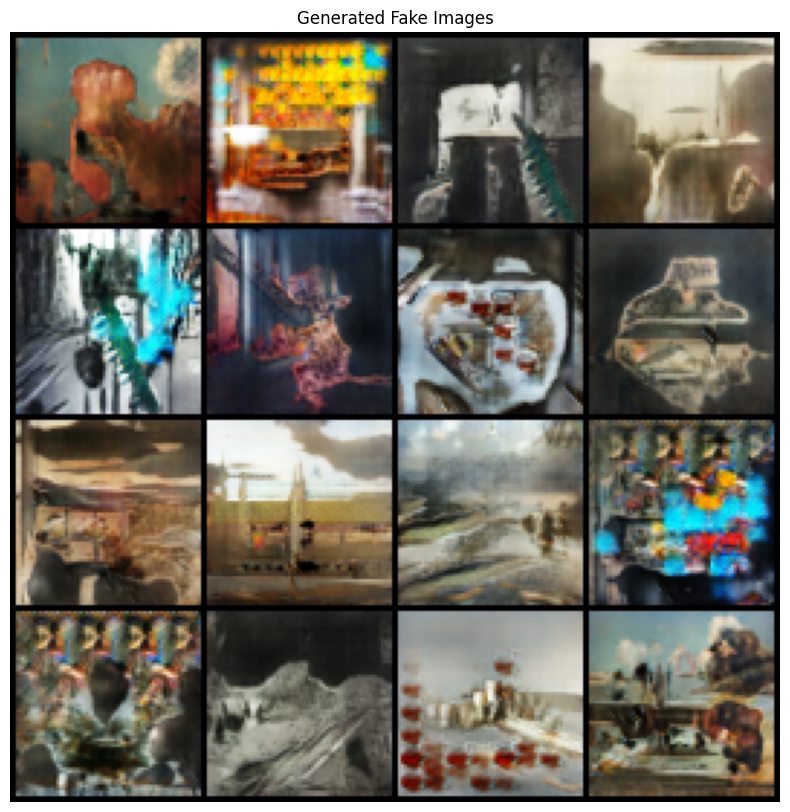

ConditionalGenerator(
  (fc): Linear(in_features=612, out_features=8192, bias=True)
  (main): Sequential(
    (0): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU(inplace=True)
    (2): Unflatten(dim=1, unflattened_size=(128, 8, 8))
    (3): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): Tanh()
  )
)

In [ ]:
G.eval()
with torch.no_grad():
    num_samples = 16
    device = next(G.parameters()).device
    z = torch.randn(num_samples, LATENT_DIM, device=device)
    # Use some prompt embeddings if conditional GAN, else just z for unconditional
    fake_images = G(z, prompt_embeddings[:num_samples].to(device))  # For conditional GAN
    # fake_images = G(z)  # For unconditional GAN

    fake_images = denormalize(fake_images)

grid_fake = vutils.make_grid(fake_images, nrow=4, padding=2)

plt.figure(figsize=(10,10))
plt.title("Generated Fake Images")
plt.axis('off')
plt.imshow(grid_fake.cpu().permute(1, 2, 0))
plt.show()
G.train()

# Training with 128 Image-Size

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Hyperparameters
IMAGE_SIZE = 128
LATENT_DIM = 100
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 2e-4
BETA1 = 0.5

# Normalization stats
mean = [0.5, 0.5, 0.5]
std = [0.5, 0.5, 0.5]

In [ ]:
# Denormalization helper for display
def denormalize(tensor):
    mean_tensor = torch.tensor(mean, device=tensor.device).view(3,1,1)
    std_tensor = torch.tensor(std, device=tensor.device).view(3,1,1)
    return tensor * std_tensor + mean_tensor

In [ ]:
# Residual block for Generator
class ResBlockG(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.BatchNorm2d(channels),
            nn.ReLU(True),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(True),
            nn.Conv2d(channels, channels, 3, padding=1),
        )
    def forward(self, x):
        return x + self.block(x)

In [ ]:
# Conditional Generator
class Generator(nn.Module):
    def __init__(self, latent_dim, embed_dim=512, base_channels=128):
        super().__init__()
        self.fc = nn.Linear(latent_dim + embed_dim, base_channels*8*8*8)  # 8x8 spatial size
        self.res_blocks = nn.Sequential(
            ResBlockG(base_channels*8),
            ResBlockG(base_channels*8)
        )
        self.upconv1 = nn.ConvTranspose2d(base_channels*8, base_channels*4, 4, 2, 1)  # 16x16
        self.upconv2 = nn.ConvTranspose2d(base_channels*4, base_channels*2, 4, 2, 1)  # 32x32
        self.upconv3 = nn.ConvTranspose2d(base_channels*2, base_channels, 4, 2, 1)    # 64x64
        self.upconv4 = nn.ConvTranspose2d(base_channels, 3, 4, 2, 1)                  # 128x128
        self.bn = nn.BatchNorm2d(base_channels*4)
        self.bn2 = nn.BatchNorm2d(base_channels*2)
        self.bn3 = nn.BatchNorm2d(base_channels)
        self.relu = nn.ReLU(True)
        self.tanh = nn.Tanh()

    def forward(self, z, embed):
        x = torch.cat([z, embed], dim=1)
        x = self.fc(x)
        x = x.view(-1, 128*8, 8, 8)
        x = self.res_blocks(x)
        x = self.relu(self.bn(self.upconv1(x)))
        x = self.relu(self.bn2(self.upconv2(x)))
        x = self.relu(self.bn3(self.upconv3(x)))
        x = self.tanh(self.upconv4(x))
        return x

In [ ]:
# Discriminator residual block
class ResBlockD(nn.Module):
    def __init__(self, in_ch, out_ch, downsample=True):
        super().__init__()
        self.conv1 = nn.utils.spectral_norm(nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.conv2 = nn.utils.spectral_norm(nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.downsample = downsample
        self.down = nn.AvgPool2d(2)
        self.skip = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(in_ch, out_ch, 1)),
            nn.AvgPool2d(2) if downsample else nn.Identity()
        )

    def forward(self, x):
        out = F.leaky_relu(self.conv1(x), 0.2)
        out = self.conv2(out)
        if self.downsample:
            out = self.down(out)
        skip = self.skip(x)
        return F.leaky_relu(out + skip, 0.2)

In [ ]:
# Conditional Discriminator
class Discriminator(nn.Module):
    def __init__(self, embed_dim=512, base_channels=64):
        super().__init__()
        self.image_net = nn.Sequential(
            nn.utils.spectral_norm(nn.Conv2d(3, base_channels, 3, padding=1)),
            nn.LeakyReLU(0.2),
            ResBlockD(base_channels, base_channels*2),
            ResBlockD(base_channels*2, base_channels*4),
            ResBlockD(base_channels*4, base_channels*8),
            ResBlockD(base_channels*8, base_channels*16),
            nn.Flatten()
        )
        self.fc_img = nn.utils.spectral_norm(nn.Linear(base_channels*16*8*8, 512))
        self.fc_embed = nn.utils.spectral_norm(nn.Linear(embed_dim, 512))
        self.fc_out = nn.utils.spectral_norm(nn.Linear(512, 1))

    def forward(self, img, embed):
        batch_size = img.size(0)
        x = self.image_net(img)
        img_feat = self.fc_img(x)          # (B, 512)
        embed_feat = self.fc_embed(embed)  # (B, 512)
        combined = F.leaky_relu(img_feat + embed_feat, 0.2)
        out = self.fc_out(combined)
        return out.squeeze(1)  # raw logits

In [ ]:
# Dataset for lazy loading images + embeddings
class LazyImageDataset(Dataset):
    def __init__(self, df, image_dir, prompt_embeddings, transform):
        self.df = df
        self.image_dir = image_dir
        self.prompt_embeddings = prompt_embeddings
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['img_name']
        img_path = os.path.join(self.image_dir, img_name)
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            raise RuntimeError(f"Invalid or missing image file: {img_name}")
        image = self.transform(image)
        prompt_embed = self.prompt_embeddings[idx]
        return image, prompt_embed

In [ ]:
# Training Setup
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

In [ ]:
df = pd.read_csv(csv_path)
df_clean = df[df['img_name'].apply(lambda x: os.path.isfile(os.path.join(image_dir, x)) if isinstance(x, str) else False)].reset_index(drop=True)

In [ ]:
clip_model, _ = clip.load("ViT-B/32", device=device)
clip_model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [ ]:
def encode_prompts(prompts, batch_size=64):
    all_embeddings = []
    num_batches = (len(prompts) + batch_size - 1) // batch_size
    for i in range(num_batches):
        batch = prompts[i*batch_size:(i+1)*batch_size]
        tokens = clip.tokenize(batch).to(device)
        with torch.no_grad(), torch.amp.autocast(device_type='cuda' if device == 'cuda' else 'cpu'):
            embeds = clip_model.encode_text(tokens)
            embeds /= embeds.norm(dim=-1, keepdim=True)
        all_embeddings.append(embeds.cpu())
    return torch.cat(all_embeddings)

In [ ]:
# Dataset and loader
dataset = LazyImageDataset(df_clean, image_dir, prompt_embeddings, transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

In [ ]:
# Initialize models
G = Generator(LATENT_DIM).to(device)
D = Discriminator().to(device)

In [ ]:
# Optimizers
opt_G = optim.Adam(G.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))

In [ ]:
# Loss & scaler
criterion = nn.BCEWithLogitsLoss()
scaler_G = torch.cuda.amp.GradScaler()
scaler_D = torch.cuda.amp.GradScaler()

<ipython-input-83-0fb6e5c2a88f>:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_G = torch.cuda.amp.GradScaler()
<ipython-input-83-0fb6e5c2a88f>:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_D = torch.cuda.amp.GradScaler()


In [ ]:
# Training loop with sample image saving
for epoch in range(1, EPOCHS+1):
    G.train()
    D.train()
    total_acc = 0
    total_batches = 0
    loop = tqdm(loader, desc=f"Epoch {epoch}")

    for real_imgs, prompt_embeds in loop:
        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        prompt_embeds = prompt_embeds.to(device).float()

        real_labels = torch.ones(batch_size, device=device)
        fake_labels = torch.zeros(batch_size, device=device)
        z = torch.randn(batch_size, LATENT_DIM, device=device)

        # Train Discriminator
        with torch.cuda.amp.autocast():
            fake_imgs = G(z, prompt_embeds)
            real_out = D(real_imgs, prompt_embeds)
            fake_out = D(fake_imgs.detach(), prompt_embeds)

            real_loss = criterion(real_out, real_labels)
            fake_loss = criterion(fake_out, fake_labels)
            d_loss = (real_loss + fake_loss) / 2

        opt_D.zero_grad()
        scaler_D.scale(d_loss).backward()
        scaler_D.step(opt_D)
        scaler_D.update()

        # Train Generator
        with torch.cuda.amp.autocast():
            fake_imgs = G(z, prompt_embeds)
            g_loss = criterion(D(fake_imgs, prompt_embeds), real_labels)

        opt_G.zero_grad()
        scaler_G.scale(g_loss).backward()
        scaler_G.step(opt_G)
        scaler_G.update()

        # Accuracy calculation
        with torch.no_grad():
            real_preds = (torch.sigmoid(real_out) >= 0.5).float()
            fake_preds = (torch.sigmoid(fake_out) < 0.5).float()
            correct = real_preds.sum() + fake_preds.sum()
            accuracy = correct / (2 * batch_size)

        total_acc += accuracy.item()
        total_batches += 1
        loop.set_postfix(D_Loss=d_loss.item(), G_Loss=g_loss.item(), D_Acc=accuracy.item())

    avg_acc = total_acc / total_batches
    print(f"Epoch {epoch} | Avg D Acc: {avg_acc:.4f}")

Epoch 1:   0%|          | 0/2000 [00:00<?, ?it/s]<ipython-input-88-732fb129a909>:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
<ipython-input-88-732fb129a909>:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1: 100%|██████████| 2000/2000 [08:01<00:00,  4.15it/s, D_Acc=0.516, D_Loss=0.693, G_Loss=0.703]


Epoch 1 | Avg D Acc: 0.4870


Epoch 2: 100%|██████████| 2000/2000 [08:01<00:00,  4.15it/s, D_Acc=0.387, D_Loss=0.695, G_Loss=0.696]


Epoch 2 | Avg D Acc: 0.4877


Epoch 3: 100%|██████████| 2000/2000 [08:01<00:00,  4.15it/s, D_Acc=0.645, D_Loss=0.687, G_Loss=0.699]


...

Epoch 45: 100%|██████████| 2000/2000 [07:50<00:00,  4.25it/s, D_Acc=0.339, D_Loss=nan, G_Loss=nan]


Epoch 45 | Avg D Acc: 0.3794


Epoch 46: 100%|██████████| 2000/2000 [07:50<00:00,  4.25it/s, D_Acc=0.355, D_Loss=nan, G_Loss=nan]


Epoch 46 | Avg D Acc: 0.3794


Epoch 47:   7%|▋         | 147/2000 [00:34<07:15,  4.25it/s, D_Acc=0.352, D_Loss=nan, G_Loss=nan]

# Testing with 64x64

In [ ]:
game_prompts = [
    "epic fantasy battle scene with knights and dragons",
    "futuristic neon-lit sci-fi city skyline at night",
    "ancient medieval castle perched on a foggy hill",
    "massive spacecraft flying over colorful planets",
    "fire-breathing dragon soaring over mountains",
    "pixel art hero character wielding a sword",
    "mystical enchanted forest glowing at twilight",
    "post-apocalyptic wasteland with ruined buildings",
    "dark dungeon corridor lit by torches",
    "space battle with laser beams and explosions",
    "magical wizard casting spells in a storm",
    "steampunk airship floating above clouds",
    "zombie apocalypse survivors in ruined city",
    "colorful fantasy village with cottages and market",
    "sci-fi robot warrior in futuristic armor",
    "underwater kingdom with glowing sea creatures",
    "ancient ruins covered in jungle vines",
    "heroic knight riding a unicorn",
    "dystopian cyberpunk street scene",
    "fantasy dragon lair filled with treasure",
]

In [ ]:
def encode_custom_prompts(prompts, batch_size=16):
    all_embeddings = []
    num_batches = (len(prompts) + batch_size - 1) // batch_size
    for i in range(num_batches):
        batch = prompts[i*batch_size:(i+1)*batch_size]
        tokens = clip.tokenize(batch).to(device)
        with torch.no_grad(), torch.amp.autocast('cuda'):
            embeds = clip_model.encode_text(tokens)
            embeds /= embeds.norm(dim=-1, keepdim=True)
        all_embeddings.append(embeds.cpu())
    return torch.cat(all_embeddings)

game_prompt_embeddings = encode_custom_prompts(game_prompts)

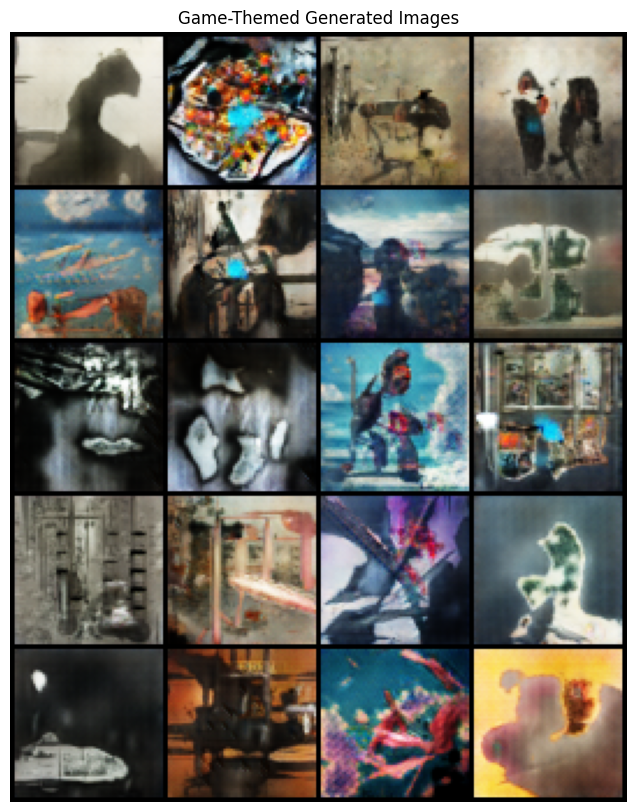

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def denormalize(tensor):
    mean = torch.tensor([0.5, 0.5, 0.5], device=tensor.device).view(3,1,1)
    std = torch.tensor([0.5, 0.5, 0.5], device=tensor.device).view(3,1,1)
    tensor = tensor * std + mean
    return tensor.clamp(0, 1)

G.eval()
with torch.no_grad():
    z = torch.randn(len(game_prompts), LATENT_DIM, device=device)
    fake_images = G(z, game_prompt_embeddings.to(device))
    fake_images = denormalize(fake_images)

grid = vutils.make_grid(fake_images, nrow=4, padding=2)
plt.figure(figsize=(10,10))
plt.title("Game-Themed Generated Images")
plt.axis('off')
plt.imshow(grid.cpu().permute(1, 2, 0))
plt.show()

# Testing with 128x128

In [ ]:
# Encode Prompts
def encode_custom_prompts_128(prompts, batch_size=16):
    all_embeddings = []
    num_batches = (len(prompts) + batch_size - 1) // batch_size
    for i in range(num_batches):
        batch = prompts[i*batch_size:(i+1)*batch_size]
        tokens = clip.tokenize(batch).to(DEVICE_128)
        with torch.no_grad(), torch.amp.autocast(device_type=DEVICE_128):
            embeds = clip_model.encode_text(tokens)
            embeds /= embeds.norm(dim=-1, keepdim=True)
        all_embeddings.append(embeds.cpu())
    return torch.cat(all_embeddings)

game_prompt_embeddings_128 = encode_custom_prompts_128(game_prompts)

In [ ]:
# Denormalization function for 128 model (same normalization assumed)
def denormalize_128(tensor):
    mean = torch.tensor([0.5, 0.5, 0.5], device=tensor.device).view(3,1,1)
    std = torch.tensor([0.5, 0.5, 0.5], device=tensor.device).view(3,1,1)
    tensor = tensor * std + mean
    return tensor.clamp(0, 1)

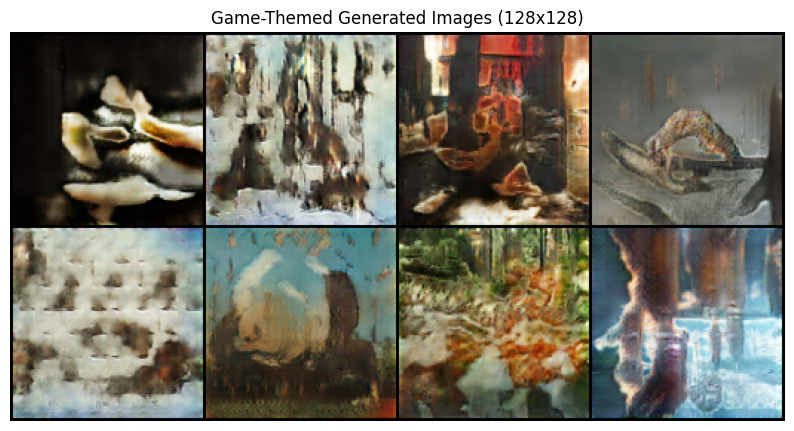

Generator128(
  (fc): Linear(in_features=612, out_features=16384, bias=True)
  (main): Sequential(
    (0): BatchNorm1d(16384, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ReLU(inplace=True)
    (2): Unflatten(dim=1, unflattened_size=(256, 8, 8))
    (3): ConvTranspose2d(256, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): BatchNorm2d(32, ep

In [ ]:
# Generate images conditioned on game prompts using 128 GAN
G_128.eval()
with torch.no_grad():
    z = torch.randn(len(game_prompts), LATENT_DIM_128, device=DEVICE_128)
    fake_images_128 = G_128(z, game_prompt_embeddings_128.to(DEVICE_128))
    fake_images_128 = denormalize_128(fake_images_128)

# Display generated images grid
grid_128 = vutils.make_grid(fake_images_128, nrow=4, padding=2)
plt.figure(figsize=(10,10))
plt.title("Game-Themed Generated Images (128x128)")
plt.axis('off')
plt.imshow(grid_128.cpu().permute(1, 2, 0))
plt.show()
G_128.train()